-------------------------------
-------------------------------
# Proyecto 3 - IA (CC3085)
* DULCE AMBROSIO - 231143
* DANIEL CHET - 231177
* GADIEL OCAÑA - 231270
* MELISA MENDIZABAL - 23778
* RENATO ROJAS - 23813
* MICAELA POP - 18960

-------------------------------
-------------------------------

-------------------------------
**¿Qué es VeritasAI?**


VeritasAI es una startup guatemalteca que automatiza la auditoría legal de contratos. En lugar de que un abogado revise manualmente cientos de reglas, el sistema las procesa lógicamente en segundos.

-------------------------------

In [1]:

# ============================================================
# IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import re as _re
import textwrap as _textwrap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, clear_output
from sympy import symbols, Implies, to_cnf


In [2]:

# ============================================================
# ESTILOS GLOBALES — escala de grises
# ============================================================

DARK_BLUE    = '#222222'
MED_BLUE     = '#555555'
LIGHT_BLUE   = '#f0f0f0'
GREEN        = '#444444'
LIGHT_GREEN  = '#f5f5f5'
ORANGE       = '#666666'
LIGHT_ORANGE = '#eeeeee'


def section_title(text, icon=''):
    """Encabezado de sección con bordes Unicode."""
    label = f'{icon} {text}'.strip() if icon else text
    width = max(len(label) + 4, 62)
    print(f'\n╔{"═" * width}╗')
    print(f'║  {label:<{width - 2}}║')
    print(f'╚{"═" * width}╝\n')


def info_box(text, color='#f9f9f9', border='#aaa'):
    """Cuadro informativo con borde Unicode, sin HTML."""
    clean = _re.sub(r'<[^>]+>', '', text).replace('&nbsp;', ' ').strip()
    clean = _re.sub(r' +', ' ', clean)
    lines = _textwrap.wrap(clean, width=68)
    width = max((max(len(l) for l in lines) if lines else 0) + 4, 72)
    print(f'┌{"─" * width}┐')
    print(f'│  ℹ {"─" * (width - 4)}│')
    for line in lines:
        print(f'│  {line:<{width - 2}}│')
    print(f'└{"─" * width}┘\n')


-------------------------------
**Sección 1 — Cláusulas de Horn: Las Reglas de VeritasAI**


Una **cláusula de Horn** es una regla con **a lo sumo una conclusión** (literal positivo). Esto permite que el motor las procese en tiempo lineal, algo crítico cuando hay miles de contratos.

-------------------------------

In [3]:

# ============================================================
# BASE DE CONOCIMIENTO (Knowledge Base) de VeritasAI
# Formato: (lista_de_premisas, conclusion)
# cláusula de Horn por regla.
# ============================================================

knowledge_base = [
    # Premisas                                  → Conclusión
    (['contrato_vencido', 'monto_alto'],           'revision_legal'),
    (['firma_invalida'],                            'bloquear_contrato'),
    (['contrato_fraudulento'],                      'auditoria_completa'),
    (['revision_legal'],                            'notificar_auditores'),
    (['bloquear_contrato'],                         'enviar_alerta_fiscal'),
    (['auditoria_completa', 'revision_legal'],       'escalar_a_fiscal'),
    (['proveedor_sin_licencia'],                     'contrato_invalido'),
    (['contrato_invalido', 'monto_alto'],            'revision_legal'),
]

section_title('Base de Conocimiento (KB) — Cláusulas de Horn')

rows = []
for i, (premisas, conclusion) in enumerate(knowledge_base, 1):
    rows.append({
        '#': i,
        'Premisas': ' ∧ '.join(premisas),
        'Conclusión': conclusion,
        'Fórmula Lógica': ' ∧ '.join(premisas) + ' → ' + conclusion,
        'Tipo': 'Definitiva',
    })

df_kb = pd.DataFrame(rows).set_index('#')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 120)
display(df_kb)

info_box(f'Total de reglas en la KB: {len(knowledge_base)} cláusulas de Horn. '
         'Cada regla tiene exactamente una conclusión, garantizando eficiencia lineal en el motor.')



╔══════════════════════════════════════════════════════════════╗
║  Base de Conocimiento (KB) — Cláusulas de Horn               ║
╚══════════════════════════════════════════════════════════════╝



,Premisas,Conclusión,Fórmula Lógica,Tipo
#,,,,
1,contrato_vencido ∧ monto_alto,revision_legal,contrato_vencido ∧ monto_alto → revision_legal,Definitiva
2,firma_invalida,bloquear_contrato,firma_invalida → bloquear_contrato,Definitiva
3,contrato_fraudulento,auditoria_completa,contrato_fraudulento → auditoria_completa,Definitiva
4,revision_legal,notificar_auditores,revision_legal → notificar_auditores,Definitiva
5,bloquear_contrato,enviar_alerta_fiscal,bloquear_contrato → enviar_alerta_fiscal,Definitiva
6,auditoria_completa ∧ revision_legal,escalar_a_fiscal,auditoria_completa ∧ revision_legal → escalar_a_fiscal,Definitiva
7,proveedor_sin_licencia,contrato_invalido,proveedor_sin_licencia → contrato_invalido,Definitiva
8,contrato_invalido ∧ monto_alto,revision_legal,contrato_invalido ∧ monto_alto → revision_legal,Definitiva


┌────────────────────────────────────────────────────────────────────────┐
│  ℹ ────────────────────────────────────────────────────────────────────│
│  Total de reglas en la KB: 8 cláusulas de Horn. Cada regla tiene       │
│  exactamente una conclusión, garantizando eficiencia lineal en el      │
│  motor.                                                                │
└────────────────────────────────────────────────────────────────────────┘



-------------------------------
**Sección 2 — Motor de Inferencia Interactivo (Modus Ponens)**


**Modus Ponens**: Si sabemos que `P → Q` es verdad, y `P` es verdad → entonces `Q` es verdad. 
VeritasAI aplica esto repetidamente para encadenar reglas y llegar a conclusiones legales.

-------------------------------

In [ ]:

# ============================================================
# MOTOR DE INFERENCIA — Forward Chaining con Modus Ponens
# ============================================================

def motor_inferencia(hechos_iniciales, kb, verbose=True):
    """Aplica Modus Ponens iterativamente (Forward Chaining)."""
    hechos = set(hechos_iniciales)
    pasos  = []
    nueva_inferencia = True
    while nueva_inferencia:
        nueva_inferencia = False
        for premisas, conclusion in kb:
            if all(p in hechos for p in premisas) and conclusion not in hechos:
                hechos.add(conclusion)
                nueva_inferencia = True
                pasos.append({
                    'regla': ' ∧ '.join(premisas) + ' → ' + conclusion,
                    'premisas': premisas,
                    'conclusion': conclusion
                })
    return hechos, pasos


# ---- INTERFAZ INTERACTIVA --------------------------------
section_title('Simulación Interactiva de Contrato')
info_box('Selecciona las condiciones del contrato y presiona "Analizar Contrato" '
         'para ver cómo VeritasAI deduce acciones legales automáticamente.')

hechos_posibles = [
    'contrato_vencido', 'monto_alto', 'firma_invalida',
    'contrato_fraudulento', 'proveedor_sin_licencia'
]
etiquetas = {
    'contrato_vencido':       ' Contrato vencido',
    'monto_alto':             ' Monto alto (> Q100,000)',
    'firma_invalida':         ' Firma inválida',
    'contrato_fraudulento':   ' Contrato fraudulento',
    'proveedor_sin_licencia': ' Proveedor sin licencia',
}

checks = {h: widgets.Checkbox(value=False, description=etiquetas[h],
                               style={'description_width': 'initial'},
                               layout=widgets.Layout(width='260px'))
          for h in hechos_posibles}

btn = widgets.Button(
    description='  Analizar Contrato',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='38px')
)
btn_reset = widgets.Button(
    description='  Resetear',
    button_style='warning',
    layout=widgets.Layout(width='120px', height='38px')
)
output = widgets.Output()

grid = widgets.GridBox(
    list(checks.values()),
    layout=widgets.Layout(grid_template_columns='repeat(3, 270px)', gap='4px')
)

def _separador(ancho=72):
    print('─' * ancho)

def analizar(_):
    hechos_sel = [h for h, cb in checks.items() if cb.value]
    with output:
        clear_output(wait=True)
        if not hechos_sel:
            print(' Selecciona al menos una condición.')
            return

        hechos_fin, pasos = motor_inferencia(hechos_sel, knowledge_base)
        conclusiones = hechos_fin - set(hechos_sel)

        _separador()
        print(' HECHOS INICIALES')
        _separador()
        for h in hechos_sel:
            print(f'   • {h}')
        print()

        if pasos:
            _separador()
            print('  PASOS DE MODUS PONENS')
            _separador()
            df_pasos = pd.DataFrame([
                {'#': i,
                 'Regla disparada': p['regla'],
                 'Conclusión inferida': '✔  ' + p['conclusion']}
                for i, p in enumerate(pasos, 1)
            ]).set_index('#')
            display(df_pasos)
        else:
            print(' Ninguna regla pudo dispararse con los hechos seleccionados.')

        print()
        if conclusiones:
            _separador()
            print('  ACCIONES LEGALES DETERMINADAS POR VERITASAI')
            _separador()
            for c in sorted(conclusiones):
                print(f'   {c}')
        else:
            _separador()
            print(' No se derivaron nuevas acciones legales.')
        _separador()

def reset(_):
    for cb in checks.values():
        cb.value = False
    with output:
        clear_output()

btn.on_click(analizar)
btn_reset.on_click(reset)

display(grid)
display(widgets.HBox([btn, btn_reset], layout=widgets.Layout(gap='10px', margin='10px 0')))
display(output)



╔══════════════════════════════════════════════════════════════╗
║  Simulación Interactiva de Contrato                          ║
╚══════════════════════════════════════════════════════════════╝

┌────────────────────────────────────────────────────────────────────────┐
│  ℹ ────────────────────────────────────────────────────────────────────│
│  Selecciona las condiciones del contrato y presiona "Analizar          │
│  Contrato" para ver cómo VeritasAI deduce acciones legales             │
│  automáticamente.                                                      │
└────────────────────────────────────────────────────────────────────────┘



GridBox(children=(Checkbox(value=False, description=' Contrato vencido', layout=Layout(width='260px'), style=C…

Output()

-------------------------------
**Sección 3 — Explicación Visual de Modus Ponens**

**Estructura formal:**  
* `P → Q` (regla)  
* `P` (hecho conocido)  
* `Q` (conclusión derivada)

-------------------------------

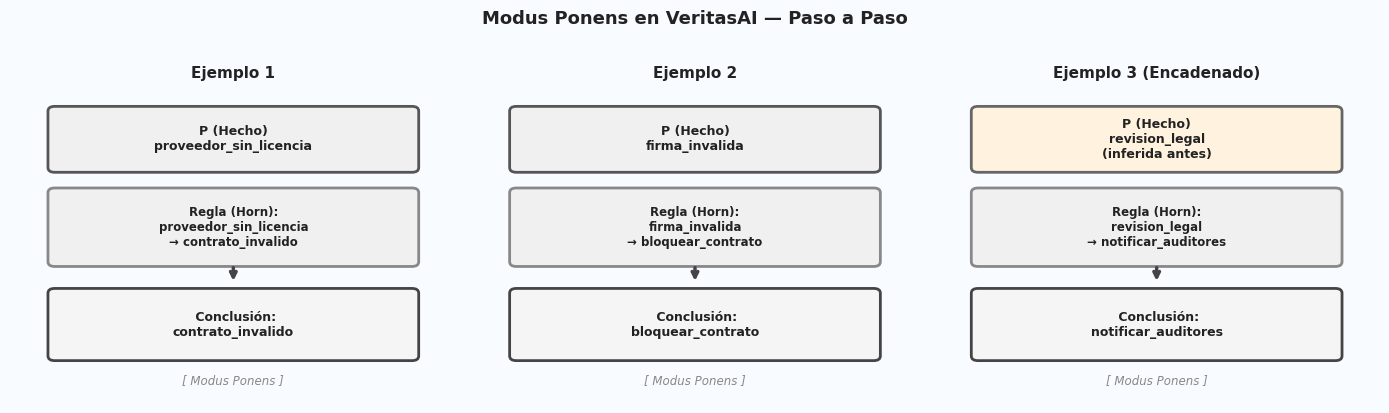

In [5]:

# ============================================================
# VISUALIZACIÓN DE MODUS PONENS
# Diagrama tipo "razonamiento paso a paso"
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#F8FBFF')

ejemplos = [
    {
        'titulo': 'Ejemplo 1',
        'premisa': 'proveedor_sin_licencia',
        'regla':   'proveedor_sin_licencia\n→ contrato_invalido',
        'conclusion': 'contrato_invalido',
        'color_p': LIGHT_BLUE, 'color_c': LIGHT_GREEN,
        'border_p': MED_BLUE,  'border_c': GREEN,
    },
    {
        'titulo': 'Ejemplo 2',
        'premisa': 'firma_invalida',
        'regla':   'firma_invalida\n→ bloquear_contrato',
        'conclusion': 'bloquear_contrato',
        'color_p': LIGHT_BLUE, 'color_c': LIGHT_GREEN,
        'border_p': MED_BLUE,  'border_c': GREEN,
    },
    {
        'titulo': 'Ejemplo 3 (Encadenado)',
        'premisa': 'revision_legal\n(inferida antes)',
        'regla':   'revision_legal\n→ notificar_auditores',
        'conclusion': 'notificar_auditores',
        'color_p': '#FFF3E0', 'color_c': LIGHT_GREEN,
        'border_p': ORANGE,   'border_c': GREEN,
    },
]

for ax, ej in zip(axes, ejemplos):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_facecolor('#F8FBFF')
    ax.set_title(ej['titulo'], fontsize=11, fontweight='bold', color=DARK_BLUE, pad=8)

    def draw_box(ax, x, y, w, h, text, fill, border, fontsize=9):
        box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                             facecolor=fill, edgecolor=border, linewidth=2)
        ax.add_patch(box)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center',
                fontsize=fontsize, color='#222', fontweight='bold', wrap=True,
                multialignment='center')

    # Caja PREMISA
    draw_box(ax, 1, 7.5, 8, 1.8, f'P (Hecho)\n{ej["premisa"]}',
             ej['color_p'], ej['border_p'])
    # Caja REGLA
    draw_box(ax, 1, 4.5, 8, 2.2, f'Regla (Horn):\n{ej["regla"]}',
             '#F0F0F0', '#888', 8.5)
    # Flecha
    ax.annotate('', xy=(5, 3.8), xytext=(5, 4.4),
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=2.5))
    # Caja CONCLUSION
    draw_box(ax, 1, 1.5, 8, 2.0, f' Conclusión:\n{ej["conclusion"]}',
             ej['color_c'], ej['border_c'])
    # Etiqueta Modus Ponens
    ax.text(5, 0.7, '[ Modus Ponens ]', ha='center', va='center',
            fontsize=8.5, color='#888', style='italic')

plt.suptitle('Modus Ponens en VeritasAI — Paso a Paso', fontsize=13,
             fontweight='bold', color=DARK_BLUE, y=1.02)
plt.tight_layout()
plt.show()


-------------------------------
**Sección 4 — Conversión a Forma Normal Conjuntiva (CNF)**

La **CNF** estandariza las reglas como conjunción de disyunciones: `(A ∨ B) ∧ (C ∨ D)`.  
El motor de resolución de VeritasAI **requiere** este formato para detectar contradicciones de manera eficiente.

-------------------------------

In [6]:

# ============================================================
# CONVERSIÓN A CNF CON SYMPY
# Mostramos la transformación algebraica de cada regla
# ============================================================

section_title('Conversión a Forma Normal Conjuntiva (CNF)')

# Definir símbolos lógicos
cv  = symbols('contrato_vencido')
ma  = symbols('monto_alto')
rl  = symbols('revision_legal')
fi  = symbols('firma_invalida')
bc  = symbols('bloquear_contrato')
cf  = symbols('contrato_fraudulento')
ac  = symbols('auditoria_completa')
psl = symbols('proveedor_sin_licencia')
ci  = symbols('contrato_invalido')

reglas_sym = [
    (Implies(cv & ma, rl),                        'contrato_vencido ∧ monto_alto → revision_legal'),
    (Implies(fi, bc),                             'firma_invalida → bloquear_contrato'),
    (Implies(cf, ac),                             'contrato_fraudulento → auditoria_completa'),
    (Implies(psl, ci),                            'proveedor_sin_licencia → contrato_invalido'),
    (Implies(rl & ac, symbols('escalar_fiscal')), 'revision_legal ∧ auditoria_completa → escalar_fiscal'),
]

rows_cnf = []
for i, (formula, nombre) in enumerate(reglas_sym, 1):
    cnf_result = to_cnf(formula)
    cnf_str = (str(cnf_result)
        .replace('contrato_vencido', 'cv')
        .replace('monto_alto', 'ma')
        .replace('revision_legal', 'rl')
        .replace('firma_invalida', 'fi')
        .replace('bloquear_contrato', 'bc')
        .replace('contrato_fraudulento', 'cf')
        .replace('auditoria_completa', 'ac')
        .replace('proveedor_sin_licencia', 'psl')
        .replace('contrato_invalido', 'ci'))
    rows_cnf.append({
        '#': i,
        'Regla Original (implicación)': nombre,
        'Transformación': 'P → Q  ≡  ¬P ∨ Q',
        'CNF Resultante': cnf_str,
    })

df_cnf = pd.DataFrame(rows_cnf).set_index('#')
pd.set_option('display.max_colwidth', None)
display(df_cnf)

info_box(
    '¿Por qué CNF? El algoritmo de resolución de VeritasAI solo puede operar sobre cláusulas '
    '(disyunciones de literales). Convertir las reglas a CNF garantiza que el motor pueda '
    'detectar contradicciones y probar teoremas de forma uniforme y automática.'
)



╔══════════════════════════════════════════════════════════════╗
║  Conversión a Forma Normal Conjuntiva (CNF)                  ║
╚══════════════════════════════════════════════════════════════╝



,Regla Original (implicación),Transformación,CNF Resultante
#,,,
1,contrato_vencido ∧ monto_alto → revision_legal,P → Q ≡ ¬P ∨ Q,rl | ~cv | ~ma
2,firma_invalida → bloquear_contrato,P → Q ≡ ¬P ∨ Q,bc | ~fi
3,contrato_fraudulento → auditoria_completa,P → Q ≡ ¬P ∨ Q,ac | ~cf
4,proveedor_sin_licencia → contrato_invalido,P → Q ≡ ¬P ∨ Q,ci | ~psl
5,revision_legal ∧ auditoria_completa → escalar_fiscal,P → Q ≡ ¬P ∨ Q,escalar_fiscal | ~ac | ~rl


┌────────────────────────────────────────────────────────────────────────┐
│  ℹ ────────────────────────────────────────────────────────────────────│
│  ¿Por qué CNF? El algoritmo de resolución de VeritasAI solo puede      │
│  operar sobre cláusulas (disyunciones de literales). Convertir las     │
│  reglas a CNF garantiza que el motor pueda detectar contradicciones y  │
│  probar teoremas de forma uniforme y automática.                       │
└────────────────────────────────────────────────────────────────────────┘



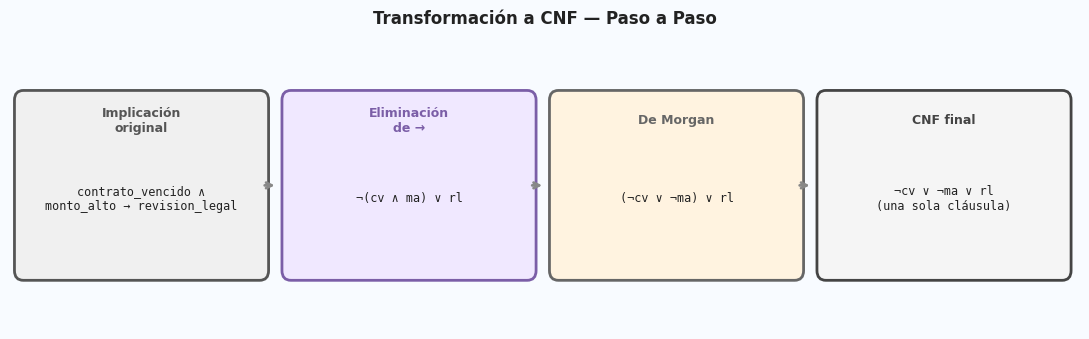

In [7]:
# ============================================================
# VISUALIZACIÓN DE UNA TRANSFORMACIÓN CNF EN DETALLE
# ============================================================

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.set_xlim(0, 24)
ax.set_ylim(0, 6)
ax.axis('off')
fig.patch.set_facecolor('#F8FBFF')
ax.set_facecolor('#F8FBFF')

pasos_cnf = [
    ('Implicación\noriginal', 'contrato_vencido ∧\nmonto_alto → revision_legal', LIGHT_BLUE, MED_BLUE),
    ('Eliminación\nde →', '¬(cv ∧ ma) ∨ rl', '#F0E8FF', '#7B5EA7'),
    ('De Morgan', '(¬cv ∨ ¬ma) ∨ rl', '#FFF3E0', ORANGE),
    ('CNF final', '¬cv ∨ ¬ma ∨ rl\n(una sola cláusula)', LIGHT_GREEN, GREEN),
]

for idx, (label_, content, fill, border) in enumerate(pasos_cnf):
    x = idx * 6 + 0.3
    box = FancyBboxPatch((x, 1.2), 5.3, 3.5, boxstyle='round,pad=0.2',
                         facecolor=fill, edgecolor=border, linewidth=2)
    ax.add_patch(box)
    ax.text(x + 2.65, 4.3, label_, ha='center', va='center',
            fontsize=9, fontweight='bold', color=border)
    ax.text(x + 2.65, 2.7, content, ha='center', va='center',
            fontsize=8.5, color='#222', multialignment='center', family='monospace')
    if idx < 3:
        ax.annotate('', xy=(x + 5.7, 2.95), xytext=(x + 5.35, 2.95),
                    arrowprops=dict(arrowstyle='->', color='#888', lw=2))

ax.set_title('Transformación a CNF — Paso a Paso', fontsize=12,
             fontweight='bold', color=DARK_BLUE, pad=10)
plt.tight_layout()
plt.show()

-------------------------------
**Sección 5 — Grafo del Motor de Inferencia**

Visualización del **flujo lógico** de VeritasAI: desde los datos del contrato hasta las acciones legales derivadas.

-------------------------------

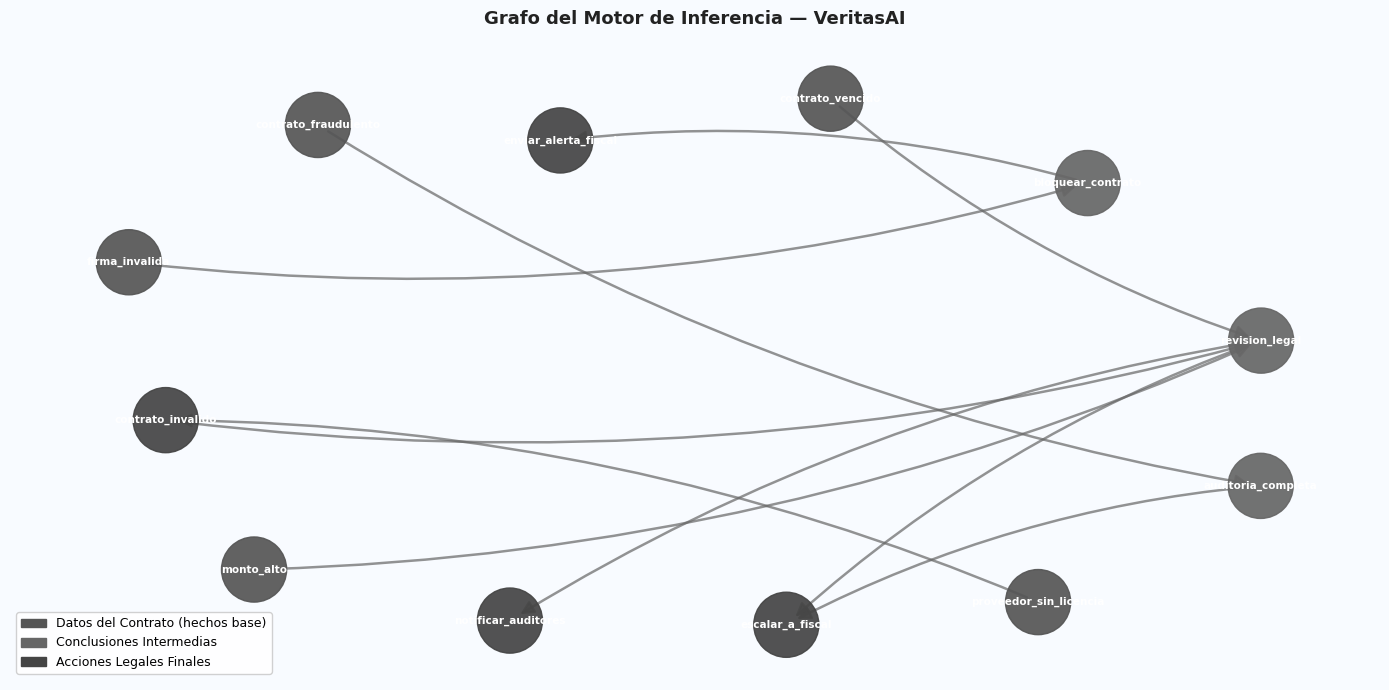

┌────────────────────────────────────────────────────────────────────────┐
│  ℹ ────────────────────────────────────────────────────────────────────│
│  El grafo muestra 12 nodos y 10 aristas de inferencia. Cada arista     │
│  representa una dependencia lógica entre un hecho y una conclusión.    │
└────────────────────────────────────────────────────────────────────────┘



In [8]:

# ============================================================
# GRAFO DE INFERENCIA 
# Muestra las dependencias entre hechos y conclusiones
# ============================================================

G = nx.DiGraph()

hechos_base = {'contrato_vencido', 'monto_alto', 'firma_invalida',
               'contrato_fraudulento', 'proveedor_sin_licencia'}

conclusiones_finales = {'notificar_auditores', 'enviar_alerta_fiscal',
                         'escalar_a_fiscal', 'contrato_invalido'}

for premisas, conclusion in knowledge_base:
    for p in premisas:
        G.add_edge(p, conclusion)

intermedios = set(G.nodes()) - hechos_base - conclusiones_finales

color_map = []
for node in G.nodes():
    if node in hechos_base:
        color_map.append(MED_BLUE)
    elif node in conclusiones_finales:
        color_map.append(GREEN)
    else:
        color_map.append(ORANGE)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F8FBFF')
ax.set_facecolor('#F8FBFF')

pos = nx.spring_layout(G, seed=42, k=2.8)

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=2200,
                        ax=ax, alpha=0.92)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True,
                        arrowsize=20, edge_color='#666',
                        width=1.8, alpha=0.7,
                        connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5,
                         font_color='white', font_weight='bold')

legend_items = [
    mpatches.Patch(color=MED_BLUE, label='Datos del Contrato (hechos base)'),
    mpatches.Patch(color=ORANGE,   label='Conclusiones Intermedias'),
    mpatches.Patch(color=GREEN,    label='Acciones Legales Finales'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=9,
          framealpha=0.9, edgecolor='#ccc')

ax.set_title('Grafo del Motor de Inferencia — VeritasAI',
             fontsize=13, fontweight='bold', color=DARK_BLUE, pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()

info_box(f'El grafo muestra {G.number_of_nodes()} nodos y '
         f'{G.number_of_edges()} aristas de inferencia. '
         'Cada arista representa una dependencia lógica entre un hecho y una conclusión.')


-------------------------------
**Sección 6 — Completitud: Ninguna Conclusión Se Pierde**

Un sistema es **completo** si puede derivar **toda** conclusión verdadera que se desprenda de las reglas.  
En VeritasAI, esto garantiza que **ningún incumplimiento legal** pase desapercibido.

-------------------------------


╔══════════════════════════════════════════════════════════════╗
║  Demostración de Completitud — Encadenamiento                ║
╚══════════════════════════════════════════════════════════════╝



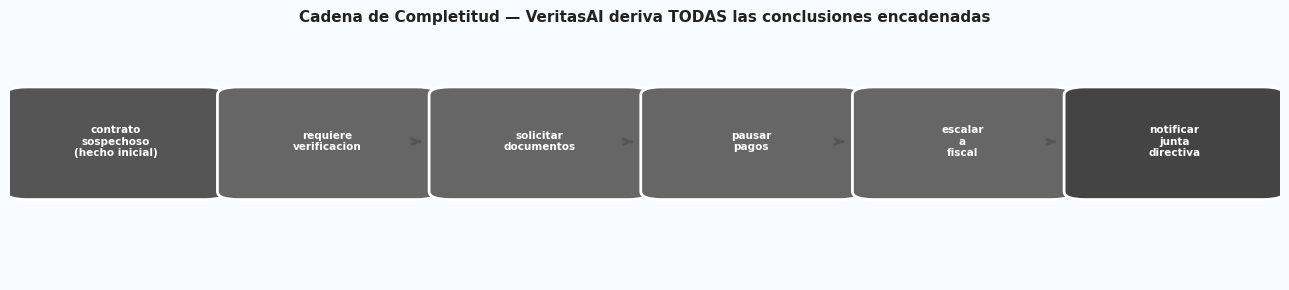

────────────────────────────────────────────────────────────────────────
HECHOS INICIALES
────────────────────────────────────────────────────────────────────────
   • contrato_sospechoso
   • monto_alto

────────────────────────────────────────────────────────────────────────
CONCLUSIONES DERIVADAS POR COMPLETITUD  (5 en total)
────────────────────────────────────────────────────────────────────────
 escalar_a_fiscal
 notificar_junta_directiva
 pausar_pagos
 requiere_verificacion
 solicitar_documentos

────────────────────────────────────────────────────────────────────────
SIN COMPLETITUD, SE PERDERÍAN:
────────────────────────────────────────────────────────────────────────
   Las reglas encadenadas más allá del 1er paso nunca se dispararían.
   VeritasAI podría clasificar como "válido" un contrato que debía
   escalar a la junta directiva.
────────────────────────────────────────────────────────────────────────


In [9]:

# ============================================================
# DEMOSTRACIÓN DE COMPLETITUD
# Encadenamiento A→B, B→C, C→D y verificación de que
# el motor encuentra TODAS las conclusiones derivables.
# ============================================================

section_title('Demostración de Completitud — Encadenamiento')

kb_completitud = [
    (['contrato_sospechoso'],        'requiere_verificacion'),
    (['requiere_verificacion'],      'solicitar_documentos'),
    (['solicitar_documentos'],       'pausar_pagos'),
    (['pausar_pagos', 'monto_alto'], 'escalar_a_fiscal'),
    (['escalar_a_fiscal'],           'notificar_junta_directiva'),
]

hechos_iniciales_c = ['contrato_sospechoso', 'monto_alto']
hechos_fin_c, pasos_c = motor_inferencia(hechos_iniciales_c, kb_completitud)
conclusiones_c = hechos_fin_c - set(hechos_iniciales_c)

cadena = ['contrato_sospechoso\n(hecho inicial)'] + \
         [p['conclusion'] for p in pasos_c]

fig, ax = plt.subplots(figsize=(13, 3))
ax.set_xlim(-0.5, len(cadena) - 0.5)
ax.set_ylim(-1, 2)
ax.axis('off')
fig.patch.set_facecolor('#F8FBFF')
ax.set_facecolor('#F8FBFF')

colores = [MED_BLUE] + [ORANGE] * max(len(cadena) - 2, 0) + [GREEN]
if len(cadena) == 1:
    colores = [MED_BLUE]

for i, (nodo, color) in enumerate(zip(cadena, colores)):
    box = FancyBboxPatch((i - 0.42, 0.1), 0.84, 1.2,
                         boxstyle='round,pad=0.1', facecolor=color,
                         edgecolor='white', linewidth=2)
    ax.add_patch(box)
    label_text = nodo.replace('_', '\n')
    ax.text(i, 0.72, label_text, ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold', multialignment='center')
    if i < len(cadena) - 1:
        ax.annotate('', xy=(i + 0.44, 0.72), xytext=(i + 0.42, 0.72),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2.2))

ax.set_title('Cadena de Completitud — VeritasAI deriva TODAS las conclusiones encadenadas',
             fontsize=11, fontweight='bold', color=DARK_BLUE, pad=12)
plt.tight_layout()
plt.show()

# ── Resultados en texto plano ──────────────────────────────
SEP = '─' * 72
print(SEP)
print('HECHOS INICIALES')
print(SEP)
for h in hechos_iniciales_c:
    print(f'   • {h}')

print()
print(SEP)
print(f'CONCLUSIONES DERIVADAS POR COMPLETITUD  ({len(conclusiones_c)} en total)')
print(SEP)
for c in sorted(conclusiones_c):
    print(f' {c}')

print()
print(SEP)
print('SIN COMPLETITUD, SE PERDERÍAN:')
print(SEP)
print('   Las reglas encadenadas más allá del 1er paso nunca se dispararían.')
print('   VeritasAI podría clasificar como "válido" un contrato que debía')
print('   escalar a la junta directiva.')
print(SEP)


------------------------
**Sección 7 — Resumen y Conexión entre Conceptos**

------------------------

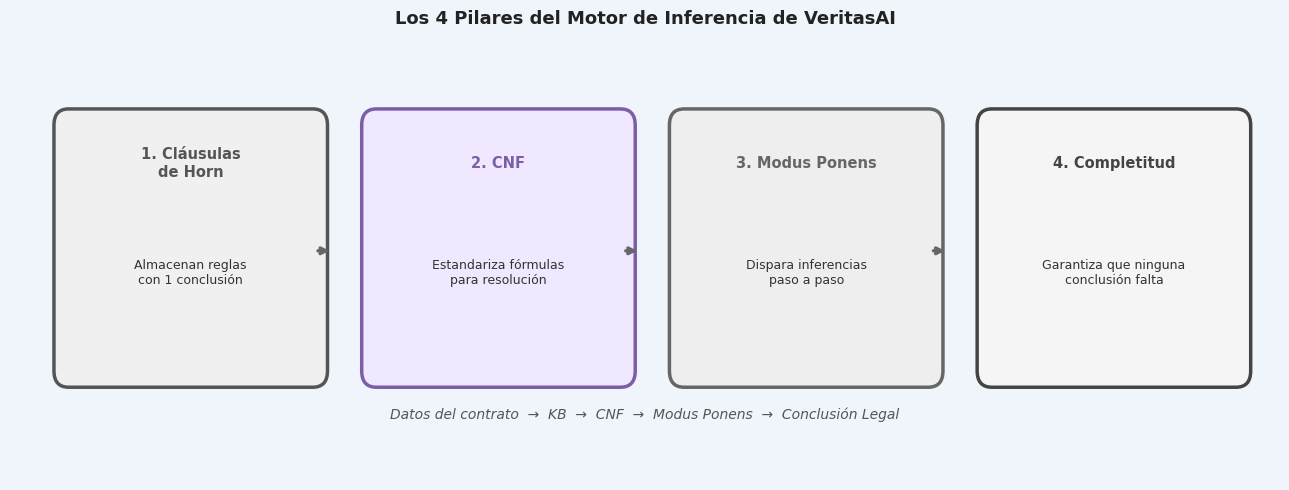

In [10]:
# ============================================================
# DIAGRAMA RESUMEN — Los 4 pilares del Motor de VeritasAI
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#F0F4FB')
ax.set_facecolor('#F0F4FB')
ax.set_xlim(0, 26)
ax.set_ylim(0, 8)
ax.axis('off')

pilares = [
    (1.2,  '1. Cláusulas\nde Horn',   'Almacenan reglas\ncon 1 conclusión',  LIGHT_BLUE, MED_BLUE),
    (7.5,  '2. CNF',                  'Estandariza fórmulas\npara resolución', '#F0E8FF', '#7B5EA7'),
    (13.8, '3. Modus Ponens',         'Dispara inferencias\npaso a paso',      LIGHT_ORANGE, ORANGE),
    (20.1, '4. Completitud',          'Garantiza que ninguna\nconclusión falta', LIGHT_GREEN, GREEN),
]

for i, (x, titulo, desc, fill, border) in enumerate(pilares):
    # Caja principal
    box = FancyBboxPatch((x, 2), 5, 4.5, boxstyle='round,pad=0.3',
                         facecolor=fill, edgecolor=border, linewidth=2.5)
    ax.add_patch(box)
    # Número
    ax.text(x + 2.5, 5.8, titulo, ha='center', va='center',
            fontsize=10.5, fontweight='bold', color=border, multialignment='center')
    ax.text(x + 2.5, 3.8, desc, ha='center', va='center',
            fontsize=9, color='#333', multialignment='center')
    # Flecha entre cajas
    if i < 3:
        ax.annotate('', xy=(x + 5.4, 4.2), xytext=(x + 5.05, 4.2),
                    arrowprops=dict(arrowstyle='->', color='#666', lw=2.5))

# Texto de flujo inferior
ax.text(13, 1.2,
        'Datos del contrato  →  KB  →  CNF  →  Modus Ponens  →  Conclusión Legal',
        ha='center', va='center', fontsize=10, color='#555', style='italic')

ax.set_title('Los 4 Pilares del Motor de Inferencia de VeritasAI',
             fontsize=13, fontweight='bold', color=DARK_BLUE, pad=14)
plt.tight_layout()
plt.show()